In [23]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
from maia2 import model, inference

In [24]:
with open('data/final_data.pkl', 'rb') as file:
    data = pickle.load(file)

In [25]:
x_acc = []
y_acc = []
z_acc = []

x_std = []
y_std = []
z_std = []

In [26]:
# Calculate the accuracy and standard deviation of move probabilities for each player across game phases
for player, player_data in data.items():
    opening_acc_cumul = 0
    opening_probs = []
    for index, move in player_data[0].iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']: # Find probability of actual move
                opening_acc_cumul += probability
                opening_probs.append(probability)
    opening_acc = opening_acc_cumul/len(player_data[0])  # Average over all moves
    opening_std = np.std(opening_probs)  # Standard deviation over all moves
    
    middle_acc_cumul = 0
    middle_probs = []
    for index, move in player_data[2].iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']: 
                middle_acc_cumul += probability
                middle_probs.append(probability)
    middle_acc = middle_acc_cumul/len(player_data[2])  
    middle_std = np.std(middle_probs)
    
    end_acc_cumul = 0
    end_probs = []
    for index, move in player_data[4].iterrows():
        for predicted_move, probability in move['move_probs'].items():
            if predicted_move == move['move']:
                end_acc_cumul += probability
                end_probs.append(probability)
    end_acc = end_acc_cumul/len(player_data[4])  
    end_std = np.std(end_probs)
    
    x_acc.append(opening_acc)
    y_acc.append(middle_acc)
    z_acc.append(end_acc)
    
    x_std.append(opening_std)
    y_std.append(middle_std)
    z_std.append(end_std)

In [27]:
# PCA to reduce dimensionality for both datasets
X_acc = np.array([x_acc, y_acc, z_acc]).T
pca_acc = PCA(n_components=3)
X_acc_pca = pca_acc.fit_transform(X_acc)
pc1_acc_variance_ratio = pca_acc.explained_variance_ratio_[0]

X_std = np.array([x_std, y_std, z_std]).T
pca_std = PCA(n_components=3)
X_std_pca = pca_std.fit_transform(X_std)
pc1_std_variance_ratio = pca_acc.explained_variance_ratio_[0]

In [28]:
# Show PCA on 3d plots
mean_acc = np.mean(X_acc, axis=0)
pc1_acc = pca_acc.components_[0]
start_acc = mean_acc - 0.037 * pc1_acc
end_acc = mean_acc + 0.037 * pc1_acc

mean_std = np.mean(X_std, axis=0)
pc1_std = pca_std.components_[0]
start_std = mean_std - 0.01 * pc1_std
end_std = mean_std + 0.01 * pc1_std

In [29]:
# Regression between PC1 and each phase scores
r2_values = []
for name, values in zip(['Opening', 'Middle', 'End'], [x_acc, y_acc, z_acc]):
    reg = LinearRegression().fit(X_acc_pca[:, 0].reshape(-1, 1), values)
    r2 = reg.score(X_acc_pca[:, 0].reshape(-1, 1), values)
    r2_values.append(r2)
    print(f'{name} phase: R^2 = {r2:.2f}')
r2_label =(
    "R² with PC1:\n"
    f"  • Opening = {r2_values[0]:.2f}\n"
    f"  • Middle = {r2_values[1]:.2f}\n"
    f"  • Endgame = {r2_values[2]:.2f}"
)

Opening phase: R^2 = 0.32
Middle phase: R^2 = 0.79
End phase: R^2 = 0.68


In [30]:
def annotate_3d(ax, x, y, z, text, x_offset=0, y_offset=0, z_offset=0, size=8, zorder=2, color='k', ha='center'):
    ax.text(x + x_offset, y + y_offset, z + z_offset, text, size=size, zorder=zorder, color=color, ha=ha)

def annotate_and_arrow_3d(ax, x, y, z, text, x_offset=0, y_offset=0, z_offset=0,  size=8, zorder=2, color='k', ha='center'):
    annotate_3d(ax, x + x_offset, y + y_offset, z + z_offset, text, size=size, zorder=zorder, color=color, ha=ha)
    
    ax.quiver(
        x + x_offset, y + y_offset, z + 0.0005,
        -x_offset, -y_offset, -0.0005,
        color='black',
        linewidth=0.8,
        arrow_length_ratio=0,
        alpha=0.8)

In [39]:
pc1_std_values = X_std_pca[:, 0]

# 2d clustering of players based on PCA components
points = np.column_stack((pc1_acc_values, pc1_std_values))

n_clusters = 4
kmeans = MiniBatchKMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels = kmeans.fit_predict(points)

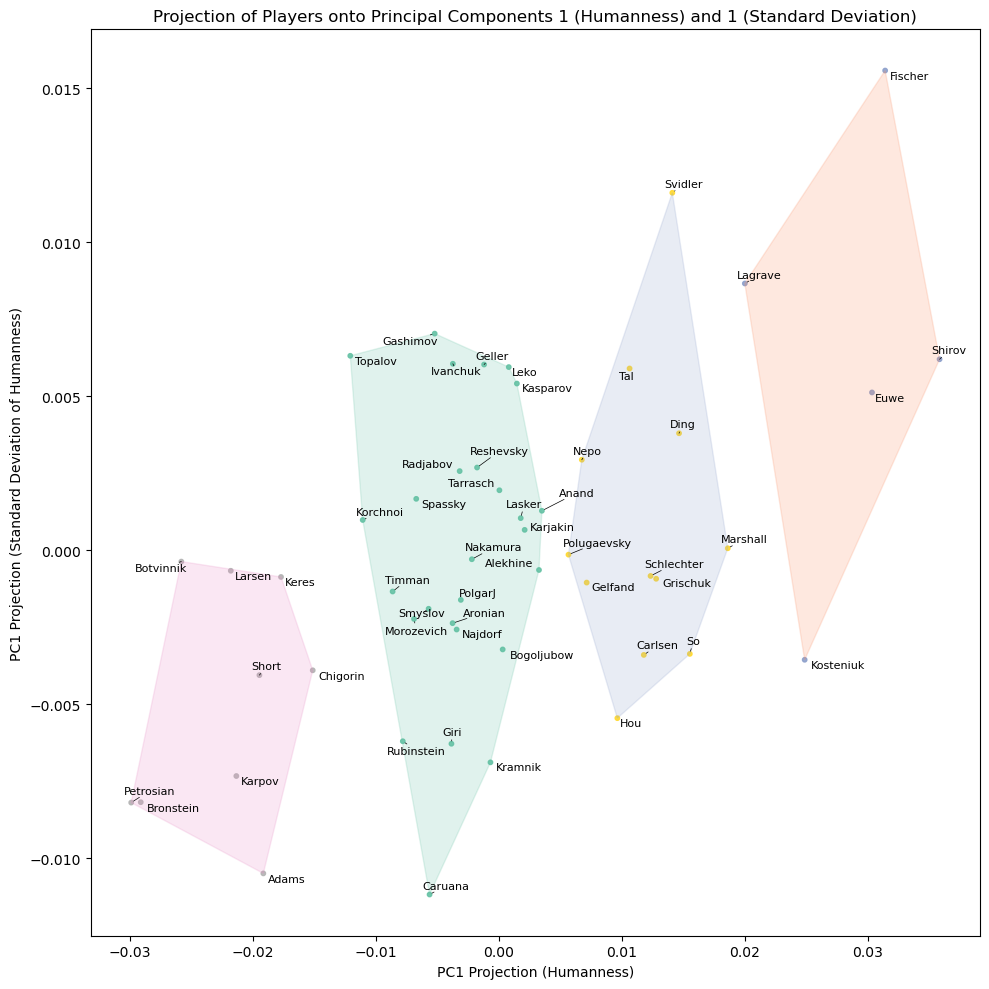

In [40]:

fig_2d = plt.figure(4, figsize=(10, 10))
scatter = plt.scatter(pc1_acc_values, pc1_std_values, c=labels, cmap='Set2', s=10, alpha=0.9)

for cluster_id in range(n_clusters):
    cluster_points = points[labels == cluster_id]
    
    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        vertices = cluster_points[hull.vertices]
        polygon = Polygon(vertices, alpha=0.2, color=scatter.cmap(cluster_id), edgecolor='k')
        plt.gca().add_patch(polygon)

texts_2d = []

for i, player in enumerate(data.keys()):
    if player == 'VachierLagrave':
        player = 'Lagrave'
    if player == 'Nepomniachtchi':
        player = 'Nepo'
        
    if i % 2 == 0:
        texts_2d.append(plt.text(pc1_acc_values[i], pc1_std_values[i], player, rotation=0, ha='center', va='bottom', fontsize=8))
    else:
        texts_2d.append(plt.text(pc1_acc_values[i], pc1_std_values[i], player, rotation=0, ha='center', va='top', fontsize=8))

adjust_text(texts_2d, arrowprops=dict(arrowstyle='-', color='black', lw=0.5), time_lim=3)

plt.xlabel('PC1 Projection (Humanness)')
plt.ylabel('PC1 Projection (Standard Deviation of Humanness)')
plt.title('Projection of Players onto Principal Components 1 (Humanness) and 1 (Standard Deviation)')
plt.tight_layout()